In [10]:
import cv2
import openslide
import matplotlib.pyplot as plt
import numpy as np

In [35]:
wsi_path = "/rsrch5/home/trans_mol_path/cercan/BE_master/0.input/flow/roi/flow/MDA12_ROI_pyramid/D0065_ROI1.tif"

wsi = openslide.OpenSlide(wsi_path)
seg_level = wsi.get_best_level_for_downsample(64)
img_rgb = np.array(wsi.read_region((0,0), seg_level, wsi.level_dimensions[seg_level]).convert('RGB'))
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
img_blur = cv2.GaussianBlur(img_gray,(7,7),0)
_, img_otsu = cv2.threshold(img_blur, 20, 255, cv2.THRESH_OTSU+cv2.THRESH_BINARY_INV)
_, mask_ink = cv2.threshold(img_gray, 50, 255, cv2.THRESH_BINARY_INV)
kernel = np.ones((3,3), np.uint8)
mask_ink = cv2.dilate(mask_ink, kernel, iterations=1)

mask_foreground = cv2.subtract(img_otsu, mask_ink)

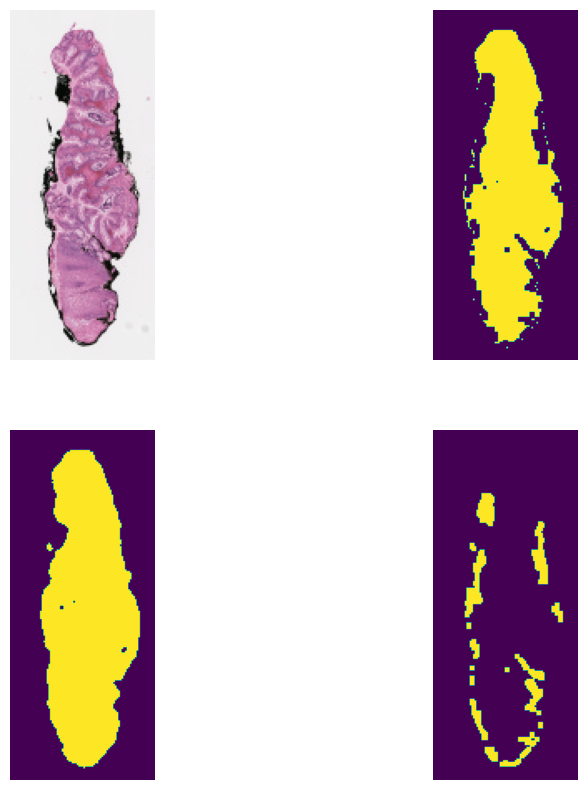

In [36]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Display the images
axs[0, 0].imshow(img_rgb)
axs[0, 0].axis('off')

axs[0, 1].imshow(mask_foreground)
axs[0, 1].axis('off')

axs[1, 0].imshow(img_otsu)
axs[1, 0].axis('off')

axs[1, 1].imshow(mask_ink)
axs[1, 1].axis('off')

plt.show()